<img src="icons/icon.png" width="50"/> ![Badge](https://img.shields.io/badge/Workshop%20SMLMS%202025-FF1010?style=for-the-badge)
## Single Molecule Tracking and Diffusion

 *[Daniel Sage](mailto:daniel.sage@epfl.ch?subject=Single%20Molecule%20Tracking%20and%20Diffusion), Ecole Polytechnique Fédérale de Lausanne, Switerzland*


In [11]:
try: 
  import andi_datasets #Install andi_datasets if not yet installed
except ImportError: 
  !pip install andi_datasets

try: 
  import trackpy #Install trackpy if not yet installed
except ImportError: 
  !pip install trackpy
    
import numpy as np
import random
import imageio
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass
from skimage.feature import peak_local_max
from sklearn.linear_model import LinearRegression
from scipy.optimize import curve_fit
from andi_datasets.utils_videos import play_video

rng = np.random.default_rng(1234)

In [12]:
FOV = np.array((200, 200))    # Field of view in pixels
STEPS = 100
DT = 1.0
N_FAST, N_SLOW = 5, 5
LEN_MIN, LEN_MAX = 40, 60
D_FAST_TRUE = 2.0
D_SLOW_TRUE = 0.5

# PSF / imaging
PSF = 1.5            # Sigma of the Gaussian PSF
INTEGRATION_TIME = 2 # Number of frame is STEPS / INTEGRATION_TIME
SHOT_NOISE, READOUT_NOISE,  = 200.0, 1.0
BACKGROUND = 5.0
# Peak finding (skimage)
THRESHOLD_DETECTION = 20

# Gaussian localization
FIT_RADIUS = max(2, int(np.ceil(2.5 * PSF)))  # half window for fit

# Tracking
SEARCH_RANGE = 12.0
MIN_LEN_FOR_MSD = 6

In [13]:
# ============================
# Class to store Track of a particle
# ============================
@dataclass
class Track:
    t:   np.ndarray
    x:   np.ndarray
    y:   np.ndarray
    msd: np.ndarray
    D: float
    grp: int         # 0 slow, 1 fast


In [14]:
# ============================
# Figure: Trajectories / Durations / MSD / D-hist
# ============================

def plot_trajectory(tracks, name, gt=True):
    fig, axs = plt.subplots(2, 2, figsize=(12, 9))

    # (1) trajectories
    ax = axs[0,0]
    for tr in tracks: ax.plot(tr.x, tr.y, lw=1.0, alpha=0.9, color='orange' if tr.grp==1 else 'blue')
    ax.set_xlim(0, FOV[1]); ax.set_ylim(0, FOV[0]); ax.invert_yaxis()
    ax.set_title(f'Trajectories {name}'); 

    # (2) durations timeline
    ax = axs[0,1]
    for i, tr in enumerate(tracks): ax.hlines(i, tr.t[0], tr.t[-1], colors='orange' if tr.grp==1 else 'blue', lw=2)
    ax.set_xlim(0, STEPS-1); ax.set_yticks([])
    ax.set_title('Start/End Timeline')

    # (3) GT MSD
    ax = axs[1,0]
    for tr in tracks: ax.plot(np.arange(len(tr.msd)) * DT, tr.msd, color='orange' if tr.grp==1 else 'blue', alpha=0.25, lw=1.0)
    ax.grid(True)
    ax.set_title(f'MSD on {name}')

    # (4) GT D histogram
    ax = axs[1,1]
    if gt:
        Ds_fast = np.array([tr.D for tr in tracks_fast], dtype=float)
        Ds_fast = Ds_fast[np.isfinite(Ds_fast)]
        Ds_slow = np.array([tr.D for tr in tracks_slow], dtype=float)
        Ds_slow = Ds_slow[np.isfinite(Ds_fast)]
        ax.hist(Ds_slow, bins=30, alpha=0.7, density=True, label=f'slow (av. {np.mean(Ds_slow):3.2f})', color='blue')
        ax.hist(Ds_fast, bins=30, alpha=0.7, density=True, label=f'fast (av. {np.mean(Ds_fast):3.2f})', color='orange')
        ax.axvline(D_SLOW_TRUE, ls='--', color='blue',  label=f'D_slow true {D_SLOW_TRUE}')
        ax.axvline(D_FAST_TRUE, ls='--', color='orange', label=f'D_fast true {D_FAST_TRUE}')
    else:
        Ds = np.array([tr.D for tr in tracks], dtype=float)
        Ds = Ds[np.isfinite(Ds)]
        ax.hist(Ds, bins=30, alpha=0.7, density=True, label=f'slow (av. {np.mean(Ds):3.2f})', color='blue')
        
    ax.grid(True); ax.legend()
    ax.set_title(f'Estimation D on {name} Tracks')

    fig.tight_layout()
    plt.show()

In [15]:
# ============================
# Compute MSD and Diffusion Coefficient
# ============================
def msd_model(t, D):
    return 4 * D * t  # 2D Brownian motion

def mean_square_displacement(x, y):
    d = x.shape[0]
    msd = np.zeros(d)
    for t in range(d):
        dx = x[t:] - x[:d-t]
        dy = y[t:] - y[:d-t]
        displacements = dx**2 + dy**2
        msd[t] = np.mean(displacements)
    return msd

def diffusion_msd(x, y, dt):
    msd = mean_square_displacement(x, y)
    time = np.arange(len(msd)) * dt
    popt, _ = curve_fit(msd_model, time[1:], msd[1:], p0=(1.0,), maxfev=10000) 
    D = popt[0]
    return D, msd

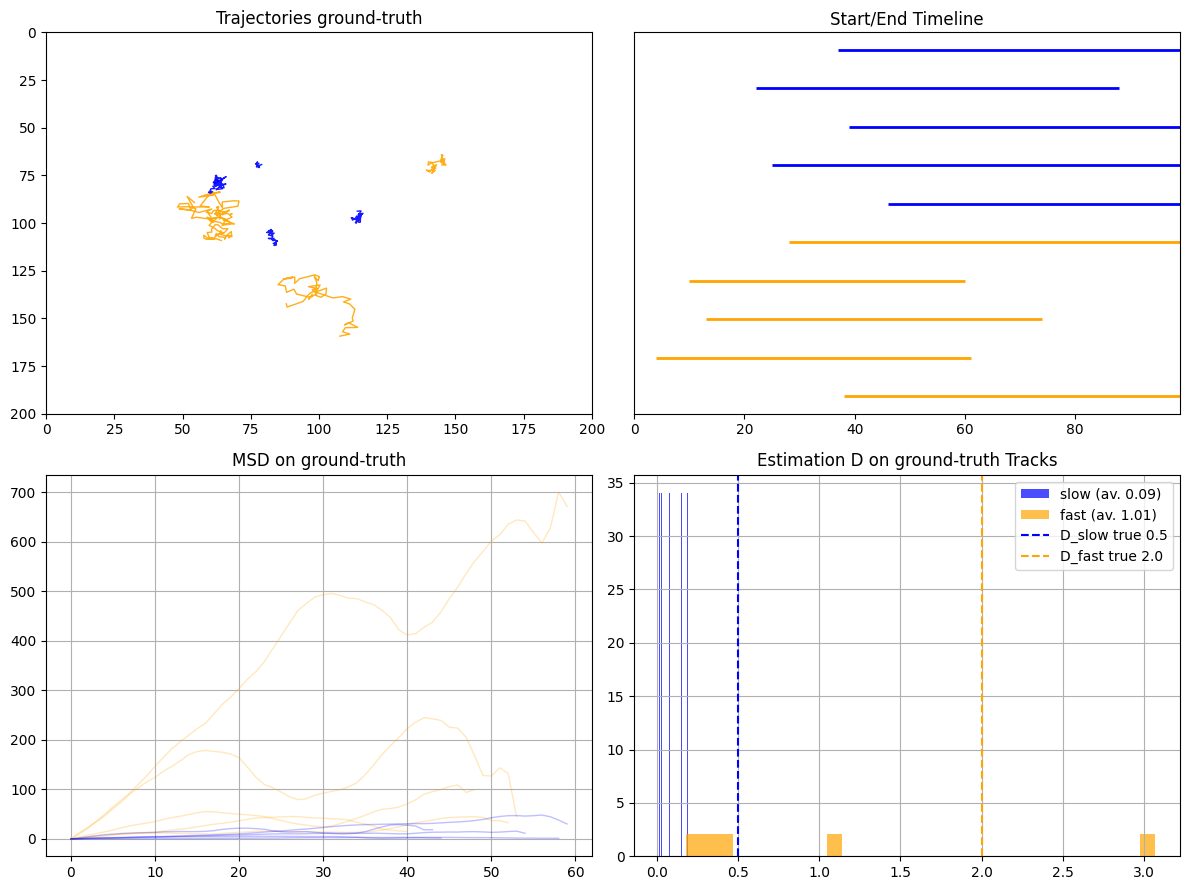

In [16]:
# ============================
# Simulation of tracks
# ============================
def generate_isotropic_brownian_trajectory(N, steps, len_min, len_max, dt, D, grp):
    tracks = []
    for i in range(N):
        length = rng.integers(len_min, len_max + 1)
        start = rng.integers(0, steps-length-1)
        trajectory = [rng.uniform(FOV/4, 3*FOV/4)] # Starting position in the center
        timepoint = [start]
        for t in range(start+1, start+length):
            position = trajectory[- 1] + rng.normal(0.0, 1.0, size=2) * np.sqrt(2 * D * dt)
            if np.all((position < 0) & (position >= FOV)): break
            trajectory.append(position)
            timepoint.append(start+t)
        t = np.array(timepoint)
        x = np.array(trajectory)[:,0]
        y = np.array(trajectory)[:,1]
        D, msd = diffusion_msd(x, y, DT)
        tracks.append(Track(t=t, x=x, y=y, msd=msd, D=D, grp=grp))
    return tracks

tracks_fast = generate_isotropic_brownian_trajectory(N_FAST, STEPS, LEN_MIN, LEN_MAX, DT, D_FAST_TRUE, 1)
tracks_slow = generate_isotropic_brownian_trajectory(N_SLOW, STEPS, LEN_MIN, LEN_MAX, DT, D_SLOW_TRUE, 0)
tracks = tracks_fast + tracks_slow

plot_trajectory(tracks, 'ground-truth')

## 

In [17]:
# ============================
# Generate frames with noise
# ============================
def add_gaussian_stamp(img, x, y, sigma, amplitude=1.0):
    h, w = img.shape
    r = int(np.ceil(3 * sigma))
    xc = int(np.floor(x)); yc = int(np.floor(y))
    x0, x1 = xc - r, xc + r; y0, y1 = yc - r, yc + r
    xi0, xi1 = max(0, x0), min(w - 1, x1)
    yi0, yi1 = max(0, y0), min(h - 1, y1)
    if xi1 < xi0 or yi1 < yi0: return
    xs = np.arange(xi0, xi1 + 1, dtype=float)
    ys = np.arange(yi0, yi1 + 1, dtype=float)
    X, Y = np.meshgrid(xs, ys)
    dx = X - x; dy = Y - y
    kernel = amplitude * np.exp(-(dx*dx + dy*dy) / (2.0 * sigma * sigma))
    img[yi0:yi1+1, xi0:xi1+1] += kernel.astype(img.dtype, copy=False)

def build_positions_by_time(tracks, steps):
    pos_by_t = [[] for _ in range(steps)]
    for tr in tracks:
        for tt, xx, yy in zip(tr.t, tr.x, tr.y):
            if 0 <= tt < steps:
                pos_by_t[tt].append((xx, yy, tr.grp))
    return [np.asarray(p, float) if p else np.empty((0,3), float) for p in pos_by_t]

def generate_frames(tracks, fov, steps, integration, sigma, shotnoise, background, readout):
    n_frames = steps // integration
    frames = np.zeros((n_frames, fov[0], fov[1]), dtype=np.float32)
    pos_by_t = build_positions_by_time(tracks, steps)
    for fi in range(n_frames):
        signal = np.zeros(fov, dtype=np.float32)
        t_start = fi * integration
        for tt in range(t_start, t_start + integration):
            for (x, y, _g) in pos_by_t[tt]:
                add_gaussian_stamp(signal, x, y, sigma=sigma, amplitude=shotnoise)
        shot = rng.poisson(signal + background).astype(np.float32)
        noisy = shot + rng.normal(0.0, readout, size=shot.shape).astype(np.float32)
        frames[fi] = np.clip(noisy, 0, None)
    return frames


frames = generate_frames(tracks, FOV, STEPS, INTEGRATION_TIME, PSF, SHOT_NOISE, BACKGROUND, READOUT_NOISE)
play_video(frames[..., np.newaxis])


INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.HTMLWriter'>


0:0 1:0 2:1 3:0 4:1 5:2 6:3 7:1 8:1 9:2 10:2 11:4 12:3 13:3 14:4 15:3 16:3 17:4 18:5 19:5 20:4 21:3 22:4 23:5 24:4 25:5 26:5 27:5 28:7 29:6 30:6 31:4 32:4 33:4 34:3 35:3 36:4 37:5 38:5 39:6 40:6 41:7 42:6 43:6 44:6 45:5 46:6 47:6 48:6 49:6 


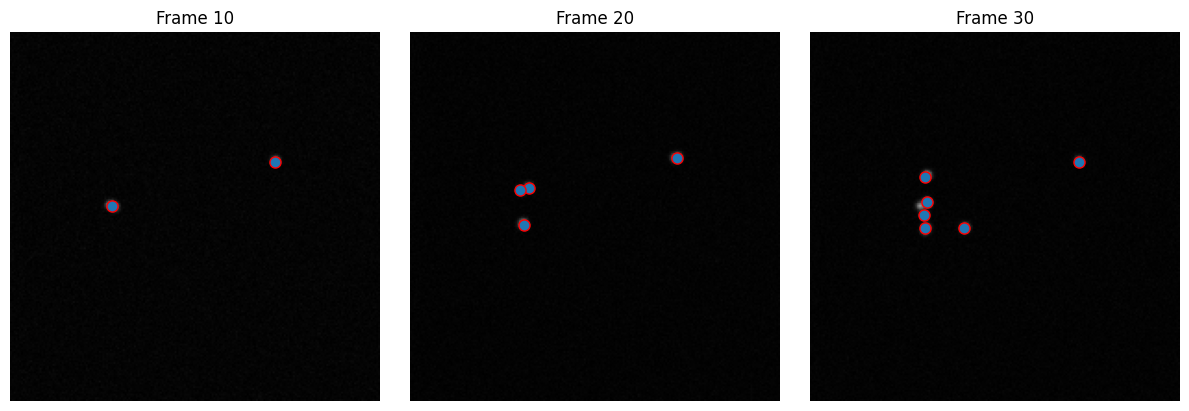

In [18]:
def detect_peaks(frame, psf_sigma, threshold_abs):
    min_distance = max(1, int(round(2 * psf_sigma)))   # local-max separation (pixels)
    coords = peak_local_max(frame, min_distance=min_distance, threshold_abs=threshold_abs, exclude_border=True)
    if coords.size <= 0: return np.empty((0,2))
    detection = np.stack([coords[:,1].astype(float), coords[:,0].astype(float)], axis=1)  # [x,y]
    return detection

def detect(frames, psf_sigma, threshold_abs):
    detections = []
    for i, frame in enumerate(frames):
        detection = detect_peaks(frame, psf_sigma, threshold_abs)  # (y,x)
        print(f'{i}:{len(detection)} ', end="", flush=True)
        detections.append(detection)
    print() 
    return detections
    
detections = detect(frames, PSF, THRESHOLD_DETECTION)

frame_ids = [10, 20, 30]
fig, axes = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)
for ax, fid in zip(axes, frame_ids):
    ax.imshow(frames[fid], cmap='gray', origin='upper')
    P = detections[fid]
    if P.size: ax.plot(P[:,0], P[:,1], 'o', ms=8, mec='r')
    ax.set_title(f'Frame {fid}')
    ax.axis('off')
    ax.set_aspect('equal', adjustable='box')

plt.show()

Frame 49: 6 trajectories present.


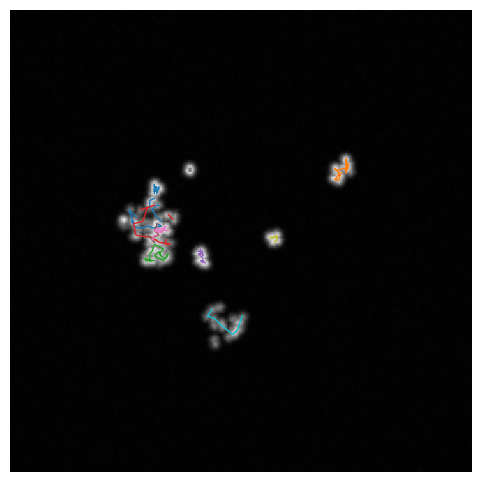

In [19]:
def link_tracks(detections_by_frame, search_range=10, memory=0, min_len=1):
    # build a tidy DataFrame: one row per detection (x,y,frame)
    rows = [{'x':x, 'y':y, 'frame':f}
            for f, arr in enumerate(detections_by_frame)
            for x, y in (arr if arr.size else [])]
    feats = pd.DataFrame(rows)
    if feats.empty: return feats
    # link with trackpy
    tracks = trackpy.link_df(feats, search_range=search_range, memory=memory, pos_columns=['x','y'])
    if min_len > 1:
        keep_ids = tracks['particle'].value_counts().loc[lambda s: s>=min_len].index
        tracks = tracks[tracks['particle'].isin(keep_ids)].copy()
    return tracks.sort_values(['particle','frame'])

tracked_particles = link_tracks(detections, search_range=SEARCH_RANGE, memory=2, min_len=6)

mip = frames.max(axis=0)
fig, ax = plt.subplots(figsize=(6,6))
ax.imshow(mip, cmap='gray', origin='upper'); ax.set_axis_off(); ax.set_aspect('equal', adjustable='box')
trackpy.plot_traj(tracked_particles, ax=ax, label=False, linewidth=1.2)   # or tracks_pix
plt.show()

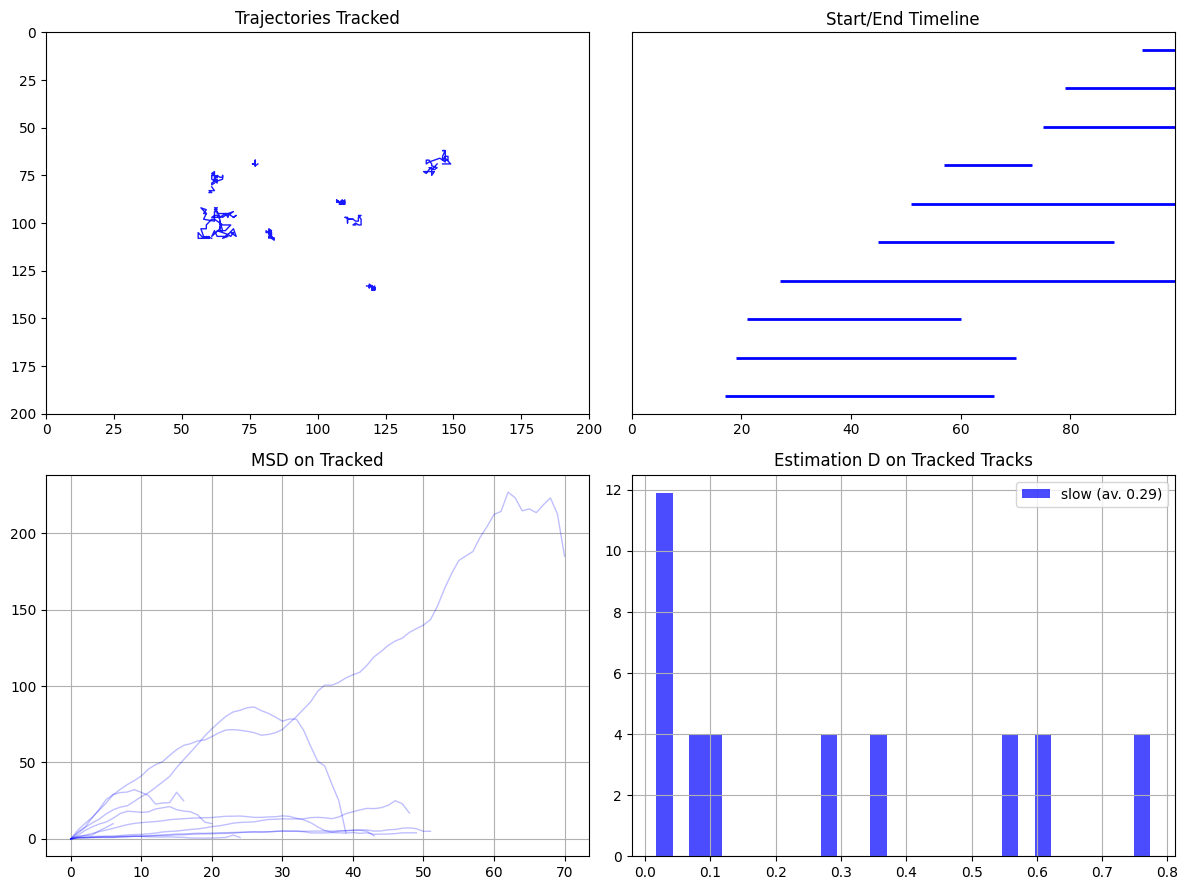

In [20]:
# tracks_df: output of tp.link_df(...) with columns ['x','y','frame','particle']
def tracks_to_xy_lists(tracks_df, min_len=2):
    df = tracks_df.sort_values(['particle', 'frame'])
    pids, xs, ys, fs = [], [], [], []
    for pid, g in df.groupby('particle', sort=False):
        if len(g) >= min_len:
            pids.append(pid)
            xs.append(g['x'].to_numpy(dtype=float))
            ys.append(g['y'].to_numpy(dtype=float))
            fs.append(g['frame'].to_numpy(dtype=int))
    return pids, xs, ys, fs

pids, xs, ys, fs = tracks_to_xy_lists(tracked_particles, min_len=MIN_LEN_FOR_MSD)

tracked = []
for x, y, f in zip(xs, ys, fs):
    D, msd = diffusion_msd(x, y, DT)
    tracked.append(Track(t=f, x=x, y=y, msd=msd, D=D, grp=0))

plot_trajectory(tracked, 'Tracked', gt=False)